In [127]:
"""
author: Federico Bellisardi
"""

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.titlesize']  = 22
plt.rcParams['axes.labelsize']  = 22
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

SAVE = True
TRANSLATION_DISTANCE_THRESHOLD = 200  # metri: ignora translazioni con distanza inferiore a questa soglia
ROTATION_ANGLE_THRESHOLD = 0  # gradi: ignora rotazioni con angolo assoluto minore di questa soglia (per ora 0)

AXIS_LABEL_SIZE = 28
TICK_LABEL_SIZE = 28
LEGEND_SIZE = 22

# CONFIG: modifica queste variabili all'inizio del notebook e rilancia dall'alto
CITY = "santiago"  # "santiago" | "madrid" | "guadalajara" | "pekin" | "caracas"
SOURCE_FILTER = "fine_grid"  # "all" | "graphs" | "fine_grid"

BASE_DIR = Path("/home/fbellisardi/code/topolity/data/data_processed")
OUTPUT_DIR = Path(f"/home/fbellisardi/code/topolity/output/wtot/{CITY}")

assert BASE_DIR.exists(), f"BASE_DIR non esiste: {BASE_DIR}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Configurazione caricata per: {CITY}")
print(f"  BASE_DIR: {BASE_DIR}")
print(f"  OUTPUT_DIR: {OUTPUT_DIR}")

# --- Helper unificati utilizzati da tutte le funzioni di plotting ---
import re
def _num_param_from_row(row):
    p = row.get("parameter", None)
    if p is None or (isinstance(p, float) and pd.isna(p)):
        m = re.search(r"([+-]?\d+(?:\.\d+)?)", str(row.get("variant", "")))
        if m:
            try:
                return float(m.group(1))
            except Exception:
                return None
        return None
    try:
        return float(p)
    except Exception:
        return None

def _extract_angle_from_fields(row):
    # Prefer explicit angle marker like `_a+180`
    for field in (row.get("variant_type", ""), row.get("variant", ""), row.get("filename", "")) :
        if not field:
            continue
        s = str(field)
        m = re.search(r"_a[+-]?(\d{1,3})", s, re.I)
        if m:
            try:
                return int(m.group(1)) % 360
            except Exception:
                continue
        # fallback: if multiple numbers present, treat last as angle (e.g., 1000m_a+180 -> [1000,180])
        nums = re.findall(r"(\d{1,4})", s)
        if len(nums) >= 2:
            try:
                return int(nums[-1]) % 360
            except Exception:
                continue
    return None

def _has_cardinal_keyword(row):
    kw = r"\b(north|east|south|west|n|e|s|w)\b"
    for field in (row.get("variant_type", ""), row.get("variant", ""), row.get("filename", "")) :
        if not field:
            continue
        if re.search(kw, str(field), re.I):
            return True
    return False

def is_cardinal_translation_row(row, trans_threshold: float = TRANSLATION_DISTANCE_THRESHOLD):
    try:
        if str(row.get("transformation_type", "")).lower() != "translation":
            return False
        # apply distance threshold when available
        p = _num_param_from_row(row)
        if p is not None and p < trans_threshold:
            return False
        angle = _extract_angle_from_fields(row)
        if angle is not None:
            return angle in (0, 90, 180, 270)
        # no numeric angle; accept only if textual cardinal keyword is present
        return _has_cardinal_keyword(row)
    except Exception:
        return False

def is_cardinal_angle_only(row):
    """Strict: require numeric angle and accept only 0/90/180/270. Do not accept textual keywords."""
    try:
        if str(row.get("transformation_type", "")).lower() != "translation":
            return False
        angle = _extract_angle_from_fields(row)
        if angle is None:
            return False
        return angle in (0, 90, 180, 270)
    except Exception:
        return False

def classify_translation_direction(row):
    angle = _extract_angle_from_fields(row)
    if angle is not None:
        if angle in (90, 270):
            return "NS"
        if angle in (0, 180):
            return "WE"
        return "other"  # non-cardinal angle
    s = str(row.get("variant", "")) + " " + str(row.get("variant_type", "")) + " " + str(row.get("filename", ""))
    s = s.lower()
    if re.search(r"\b(north|south|n|s)\b", s):
        return "NS"
    if re.search(r"\b(east|west|e|w)\b", s):
        return "WE"
    return None

✓ Configurazione caricata per: santiago
  BASE_DIR: /home/fbellisardi/code/topolity/data/data_processed
  OUTPUT_DIR: /home/fbellisardi/code/topolity/output/wtot/santiago


In [128]:
def find_result_csvs(city: str, source_filter: str = "all"):
    city_dir = BASE_DIR / city

    if not city_dir.exists():
        raise FileNotFoundError(f"Directory città non trovata: {city_dir}")

    csv_paths = []

    if source_filter in ["all", "graphs"]:
        graphs_dir = city_dir / "graphs"
        if graphs_dir.exists():
            csv_paths.extend(list(graphs_dir.glob("*.csv")))

    if source_filter in ["all", "fine_grid"]:
        # provo diverse varianti possibili del CSV fine_grid (incluso _old_length_bug)
        fine_grid_dir = city_dir / "graphs_fine_grid"
        candidates = [
            # "fine_grid_gravitational_work_old_length_bug.csv",
            # "fine_grid_gravitational_work_length_bug.csv",
            "fine_grid_gravitational_work.csv",
            # "fine_grid_gravitational_work.bak.csv",
        ]
        for name in candidates:
            p = fine_grid_dir / name
            if p.exists():
                csv_paths.append(p)
                break
        if source_filter == "fine_grid" and not csv_paths:
            raise FileNotFoundError(f"CSV fine_grid non trovato in {fine_grid_dir}; cercati: {candidates}")

    if source_filter == "graphs" and not csv_paths:
        print("Nessun CSV trovato in graphs/, cerco in fine_grid...")
        fine_grid_csv = city_dir / "graphs_fine_grid" / "fine_grid_gravitational_work.csv"
        if fine_grid_csv.exists():
            csv_paths.append(fine_grid_csv)

    if not csv_paths:
        raise FileNotFoundError(f"Nessun CSV trovato in {city_dir} con filter={source_filter}")

    return sorted(dict.fromkeys(csv_paths))


In [129]:
def normalize_csv_format(df: pd.DataFrame, filename: str) -> pd.DataFrame:
    """Normalize common CSV variants to a consistent schema.

    This fills or renames commonly seen columns so downstream code
    can rely on `variant`, `variant_type`, `parameter`, and `filename`.
    If the CSV lacks any recoverable identifier for `variant`, raises ValueError.
    """
    df = df.copy()

    # common rename aliases
    rename_map = {}
    if "file" in df.columns and "filename" not in df.columns:
        rename_map["file"] = "filename"
    if "name" in df.columns and "filename" not in df.columns:
        rename_map["name"] = "filename"
    if "file_name" in df.columns and "filename" not in df.columns:
        rename_map["file_name"] = "filename"
    if rename_map:
        df = df.rename(columns=rename_map)

    # ensure filename exists when possible
    if "filename" in df.columns:
        df["filename"] = df["filename"].astype(str)

    # derive `variant` from filename when missing
    if "variant" not in df.columns:
        if "variant_name" in df.columns:
            df["variant"] = df["variant_name"].astype(str)
        elif "filename" in df.columns:
            df["variant"] = df["filename"].apply(lambda s: Path(s).stem)
        else:
            # cannot recover a variant identifier
            raise ValueError("Cannot normalize CSV: 'variant' or 'filename' not found")

    # ensure parameter and variant_type exist
    if "parameter" not in df.columns:
        df["parameter"] = None
    if "variant_type" not in df.columns:
        df["variant_type"] = df["variant"].astype(str)

    return df


def remove_duplicate_variants(df: pd.DataFrame) -> pd.DataFrame:
    """Drop duplicate variant rows keeping the first occurrence."""
    if "variant" in df.columns:
        return df.drop_duplicates(subset=["variant"], keep="first").copy()
    return df.copy()


In [130]:
def classify_transformation_type(variant: str) -> str:
    if pd.isna(variant):
        return "other"

    variant_lower = str(variant).lower()

    if "original" in variant_lower:
        return "original"
    elif "rot" in variant_lower or "rotation" in variant_lower:
        return "rotation"
    elif "trans" in variant_lower or "translation" in variant_lower:
        # Non-cardinal angles (_a+NNN where NNN not in {000,090,180,270}) → random_translation
        import re as _re
        m = _re.search(r"_a[+-]?(\d{1,3})", variant_lower)
        if m:
            angle = int(m.group(1)) % 360
            if angle not in (0, 90, 180, 270):
                return "random_translation"
        return "translation"
    elif "scale" in variant_lower or "scal" in variant_lower:
        return "scale"
    else:
        return "other"

def load_all_results(city: str, source_filter: str = "all", exclude_scale: bool = False) -> pd.DataFrame:
    csv_paths = find_result_csvs(city, source_filter)
    print(f'\nCaricamento di {len(csv_paths)} file CSV...\n')

    all_data = []

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        try:
            df = normalize_csv_format(df, csv_path.name)
        except ValueError as e:
            print(f"  Skip {csv_path.name}: {e}")
            continue

        df = remove_duplicate_variants(df)

        if "transformation_type" not in df.columns:
            type_source = df["variant_type"] if "variant_type" in df.columns else df["variant"]
            df["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)

        df["city"] = city
        df["source_file"] = str(csv_path.relative_to(BASE_DIR))
        df["source_folder"] = csv_path.parent.name

        print(f"  Caricati {len(df)} record da {csv_path.parent.name}/{csv_path.name}")
        all_data.append(df)

    if not all_data:
        raise ValueError(f'Nessun CSV valido trovato per {city}')

    combined = pd.concat(all_data, ignore_index=True)

    if "transformation_type" not in combined.columns:
        type_source = combined["variant_type"] if "variant_type" in combined.columns else combined["variant"]
        combined["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)

    # Filtra translazioni troppo corte (soglia hardcodata in metri)
    try:
        before = len(combined)

        def _extract_trans_distance(row):
            if str(row.get("transformation_type", "")) != "translation":
                return None
            # prova prima la colonna `parameter`
            param = row.get("parameter", None)
            try:
                if param is None or (isinstance(param, float) and pd.isna(param)):
                    raise ValueError()
                return float(param)
            except Exception:
                import re
                m = re.search(r"(\d+(?:\.\d+)?)", str(row.get("variant", "")))
                if m:
                    try:
                        return float(m.group(1))
                    except Exception:
                        return None
                return None

        combined["__trans_distance"] = combined.apply(_extract_trans_distance, axis=1)
        combined = combined[~((combined["transformation_type"] == "translation") & (combined["__trans_distance"].notna()) & (combined["__trans_distance"] < TRANSLATION_DISTANCE_THRESHOLD))].copy()
        if "__trans_distance" in combined.columns:
            combined = combined.drop(columns=["__trans_distance"])
        removed = before - len(combined)
        if removed > 0:
            print(f'  🔍 Rimossi {removed} record di tipo "translation" con distanza < {TRANSLATION_DISTANCE_THRESHOLD} m')
    except Exception:
        pass

    if exclude_scale:
        before = len(combined)
        combined = combined[combined["transformation_type"] != "scale"].copy()
        removed = before - len(combined)
        if removed > 0:
            print(f'  🔍 Rimossi {removed} record di tipo "scale"')

    print(f'\nTotale: {len(combined)} record da {len(all_data)} file')
    return combined

In [131]:
def plot_combined_work_comparison(results_df: pd.DataFrame, out_png: Path):
    from matplotlib.ticker import ScalarFormatter
    import matplotlib as mpl
    from matplotlib.patches import Patch

    mpl.rcParams["text.usetex"] = False
    mpl.rcParams["mathtext.default"] = "regular"

    def format_float(value, decimals: int = 2) -> str:
        try:
            text = f"{float(value):.{decimals}f}"
            return text.rstrip("0").rstrip(".")
        except Exception:
            return str(value)

    def format_variant_label(row) -> str:
        variant = str(row.get("variant", ""))
        variant_type = str(row.get("variant_type", row.get("transformation_type", ""))).lower()
        filename = str(row.get("filename", ""))
        parameter = row.get("parameter", None)

        if variant == "original" or "original" in variant.lower() or "original" in filename.lower():
            return "original"

        if variant_type.startswith("rotation") or "rot" in variant.lower() or "rotation" in variant.lower():
            angle = parameter
            if angle is None or pd.isna(angle):
                import re
                match = re.search(r"([+-]?\\d+(?:\\.\\d+)?)", variant)
                angle = float(match.group(1)) if match else None
            if angle is not None:
                sign = "+" if float(angle) >= 0 else "-"
                return f"rot {sign}{format_float(abs(angle), 2)}°"
            return variant.replace("_", " ")

        if variant_type.startswith("translation") or "trans" in variant.lower() or "translation" in variant.lower():
            distance = parameter
            if distance is None or pd.isna(distance):
                import re
                match = re.search(r"([+-]?\\d+(?:\\.\\d+)?)", variant)
                distance = float(match.group(1)) if match else None

            direction = ""
            if variant_type.startswith("translation_"):
                direction = variant_type.split("_", 1)[1]
            elif "_a" in filename:
                direction = filename.split("_a", 1)[1].split(".", 1)[0]

            direction = str(direction).replace("+", "")
            # format distance nicely
            if distance is not None:
                try:
                    distance = int(round(float(distance)))
                except Exception:
                    distance = str(distance)
            if direction:
                return f"T{distance} {direction}"
            if distance is not None:
                return f"T{distance}"
            return variant.replace("_", " ")

        if variant_type.startswith("scale") or "scale" in variant.lower() or "scal" in variant.lower():
            factor = parameter
            if factor is None or pd.isna(factor):
                import re
                match = re.search(r"([0-9]+(?:\\.[0-9]+)?)", variant)
                factor = float(match.group(1)) if match else None

            axis = ""
            if variant_type.startswith("scale_"):
                axis = variant_type.split("_", 1)[1]
            elif "scale_" in filename:
                pieces = filename.split("scale_", 1)[1].split("_", 1)
                axis = pieces[0] if pieces else ""

            axis = str(axis).upper()
            factor_text = format_float(factor, 3) if factor is not None else "?"
            if axis:
                return f"scale {axis} {factor_text}"
            return f"scale {factor_text}"

        return variant.replace("_", " ")

    df = results_df.copy()
    df = df.drop_duplicates(subset=["variant"], keep="first")

    # Ensure transformation_type exists
    if "transformation_type" not in df.columns:
        type_source = df["variant_type"] if "variant_type" in df.columns else df["variant"]
        df["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)

    # derive numeric parameter using unified helper
    df["__param_num"] = df.apply(_num_param_from_row, axis=1)

    # Keep only translations that are cardinal (and above distance threshold) using unified helper
    df = df[(df["transformation_type"] != "translation") | df.apply(is_cardinal_translation_row, axis=1)].copy()

    original = df[df["transformation_type"] == "original"].copy()
    if original.empty:
        raise ValueError("No row")

    original_value = original["energy_plot"].iloc[0]

    # Select top transformations per type (rotation/translation/random_translation/scale)
    eligible = df[(df["transformation_type"] != "original") & (df["transformation_type"].isin(["rotation", "translation", "random_translation", "scale"]))].copy()
    if eligible.empty:
        raise ValueError("Nessuna trasformazione valida trovata per il barplot")

    selected_parts = []
    for trans_type in ["rotation", "translation", "random_translation", "scale"]:
        subset = eligible[eligible["transformation_type"] == trans_type].sort_values("energy_plot", ascending=False).copy()
        if subset.empty:
            continue

        subset["__plot_label"] = subset.apply(format_variant_label, axis=1)
        subset = subset.drop_duplicates(subset=["__plot_label"], keep="first").head(3)
        selected_parts.append(subset)

    if not selected_parts:
        raise ValueError("Nessuna trasformazione valida trovata per il barplot")

    selected = pd.concat(selected_parts, ignore_index=False)
    if "__plot_label" in selected.columns:
        selected = selected.drop(columns=["__plot_label"])
    selected = selected.sort_values(["transformation_type", "energy_plot"], ascending=[True, False])
    df = pd.concat([original, selected], ignore_index=True)
    df = df.reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 6))

    palette = {
        "original": "#E63946",
        "rotation": "#fdae61",
        "translation": "#2b83ba",
        "random_translation": "#9b59b6",
        "scale": "#2ca25f",
    }
    colors = df["transformation_type"].map(palette).fillna("#7f7f7f")

    bars = ax.bar(
        range(len(df)),
        df["energy_plot"],
        color=colors,
        alpha=0.88,
        edgecolor="black",
        linewidth=0.8,
    )

    for i, v in enumerate(df["variant"]):
        if str(v) == "original":
            bars[i].set_edgecolor("black")
            bars[i].set_linewidth(2)

    formatted_labels = [format_variant_label(row) for _, row in df.iterrows()]

    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(formatted_labels, rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)
    ax.tick_params(axis="x", length=0, pad=6)

    ax.set_ylabel(r'$W_{TOT}$ (J)',  fontsize=TICK_LABEL_SIZE)

    ax.grid(False)
    plt.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((13,13))
    ax.yaxis.set_major_formatter(sci_formatter)
    ax.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)
    ax.yaxis.get_offset_text().set_fontsize(TICK_LABEL_SIZE)

    legend_handles = [Patch(facecolor=color, edgecolor="black", label=label) for label, color in palette.items()]

    plt.tight_layout()
    if SAVE:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"Salvato PNG: {out_png}")

        out_pdf = out_png.with_suffix(".pdf")
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        print(f"Salvato PDF: {out_pdf}")

    plt.show()

In [132]:
def plot_boxplot_by_transformation(results_df: pd.DataFrame, out_png: Path):
    df = results_df.copy()
    df = df.drop_duplicates(subset=["variant"], keep="first")
    
    if "transformation_type" not in df.columns:
        type_source = df["variant_type"] if "variant_type" in df.columns else df["variant"]
        df["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)
    
    palette = {
        "original": "#E63946",
        "rotation": "#fdae61",
        "translation": "#2b83ba",
        "scale": "#2ca25f",
    }
    
    original_df = df[df["transformation_type"] == "original"].copy()
    if original_df.empty:
        print("Nessun dato originale trovato.")
        return
    
    original_value = float(original_df["energy_plot"].iloc[0])
    
    # derive parameter numerico con helper unificato
    df["__param_num"] = df.apply(_num_param_from_row, axis=1)
    
    df_plot = df[df["transformation_type"].isin(["rotation", "translation", "scale"])].copy()
    if df_plot.empty:
        print("Nessun dato di trasformazione trovato.")
        if "__param_num" in df.columns:
            df.drop(columns=["__param_num"], inplace=True)
        return
    
    # Filtra translazioni e rotazioni sotto soglia usando helper unificato
    def _above_threshold(row):
        t = row.get("transformation_type", "")
        if t == "translation":
            return is_cardinal_translation_row(row)
        if t == "rotation":
            p = _num_param_from_row(row)
            if p is None:
                return True
            return abs(float(p)) >= ROTATION_ANGLE_THRESHOLD
        return True
    
    df_plot = df_plot[df_plot.apply(_above_threshold, axis=1)].copy()
    
    # Keep only cardinal translations (unified helper)
    df_plot = df_plot[(df_plot["transformation_type"] != "translation") | df_plot.apply(is_cardinal_translation_row, axis=1)].copy()
    
    if df_plot.empty:
        print("Dopo il filtraggio per soglia e cardinalità non ci sono trasformazioni da mostrare.")
        if "__param_num" in df.columns:
            df.drop(columns=["__param_num"], inplace=True)
        return
    
    order = ["rotation", "translation", "scale"]
    
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.boxplot(
        data=df_plot,
        x="transformation_type",
        y="energy_plot",
        hue="transformation_type",
        order=order,
        palette=palette,
        linewidth=3,
        showfliers=False,
        dodge=False,
        legend=False,
        ax=ax,
    )
    
    ax.axhline(y=original_value, color=palette["original"], linewidth=2.5, zorder=3)
    
    ax.grid(False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    from matplotlib.ticker import ScalarFormatter
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((13, 13))
    ax.yaxis.set_major_formatter(sci_formatter)
    ax.yaxis.get_offset_text().set_fontsize(TICK_LABEL_SIZE)
    
    plt.tight_layout()
    if SAVE:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, dpi=300, bbox_inches='tight')
        print(f'Salvato PNG: {out_png}')
        
        out_pdf = out_png.with_suffix('.pdf')
        plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
        print(f'Salvato PDF: {out_pdf}')
    
    if "__param_num" in df.columns:
        df.drop(columns=["__param_num"], inplace=True)
    
    plt.show()

In [133]:
def plot_restored_work_vs_parameter(df: pd.DataFrame, out_png: Path = None):
    """Restore original fine_grid plots from pipeline_production but arrange on 3 rows:
    Row 1: Translations (NS and WE) as two side-by-side panels
    Row 2: Rotations (full-width)
    Row 3: Scales (NS and EW) as two side-by-side panels

    Applies TRANSLATION_DISTANCE_THRESHOLD and ROTATION_ANGLE_THRESHOLD. Does not
    save files unless SAVE == True (shows inline otherwise).
    """
    import numpy as np
    import matplotlib.gridspec as gridspec

    energy_col = None
    for candidate in ["energy_plot", "total_energy_3d_J", "total_energy_on_3d_path_J", "total_energy_3d_J"]:
        if candidate in df.columns:
            energy_col = candidate
            break
    if energy_col is None:
        raise KeyError("No suitable energy column found for plotting")

    d = df.copy()
    d = d.drop_duplicates(subset=["variant"], keep="first")
    if "transformation_type" not in d.columns:
        type_source = d["variant_type"] if "variant_type" in d.columns else d["variant"]
        d["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)

    # derive numeric parameter using unified helper
    d["__param_num"] = d.apply(_num_param_from_row, axis=1)

    orig = d[d["transformation_type"] == "original"]
    if orig.empty:
        raise ValueError("Original variant not found")
    original_energy = float(orig[energy_col].iloc[0])

    # translations: select rows classified as translation and use strict angle-only filter (user request)
    trans_df = d[d["transformation_type"].astype(str).str.lower() == "translation"].copy()
    if not trans_df.empty:
        # Keep only those with numeric angle equal to 0,90,180,270
        trans_df = trans_df[trans_df.apply(is_cardinal_angle_only, axis=1)].copy()

    # rotations: select rows classified as rotation and above threshold
    rot_df = d[d["transformation_type"].astype(str).str.lower() == "rotation"].copy()
    if not rot_df.empty:
        rot_df = rot_df[rot_df["__param_num"].notna() & (rot_df["__param_num"].abs() >= ROTATION_ANGLE_THRESHOLD)].copy()

    # scales
    scale_df = d[d["transformation_type"].astype(str).str.lower() == "scale"].copy()

    # split translations into NS and WE using unified direction classifier
    trans_ns_list = []
    trans_we_list = []
    if not trans_df.empty:
        for _, row in trans_df.iterrows():
            dirc = classify_translation_direction(row)
            if dirc == "NS":
                trans_ns_list.append(row.to_frame().T)
            elif dirc == "WE":
                trans_we_list.append(row.to_frame().T)
            else:
                trans_we_list.append(row.to_frame().T)
    df_trans_ns = pd.concat(trans_ns_list, ignore_index=True) if trans_ns_list else pd.DataFrame()
    df_trans_we = pd.concat(trans_we_list, ignore_index=True) if trans_we_list else pd.DataFrame()

    # scales split
    df_scale_ns = scale_df[scale_df["variant_type"].astype(str).str.contains("ns")].copy() if not scale_df.empty else pd.DataFrame()
    df_scale_ew = scale_df[scale_df["variant_type"].astype(str).str.contains("ew")].copy() if not scale_df.empty else pd.DataFrame()

    # Create figure with GridSpec: 3 rows, 2 columns; middle row rotation spans both columns
    fig = plt.figure(figsize=(18, 15))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 0.7, 1], hspace=0.35, wspace=0.25)

    ax_t_ns = fig.add_subplot(gs[0, 0])
    ax_t_we = fig.add_subplot(gs[0, 1])
    ax_rot = fig.add_subplot(gs[1, :])
    ax_s_ns = fig.add_subplot(gs[2, 0])
    ax_s_ew = fig.add_subplot(gs[2, 1])

    # helper to extract distance (prefer __param_num, fallback to first numeric in variant/filename)
    def _extract_distance_from_row(r):
        dval = r.get("__param_num")
        if dval is not None and not (isinstance(dval, float) and pd.isna(dval)):
            return float(dval)
        m = re.search(r"(\d+(?:\.\d+)?)", str(r.get("variant", "")))
        if m:
            try:
                return float(m.group(1))
            except Exception:
                return float('nan')
        return float('nan')

    # Plot translations N-S (North positive to the right, South negative to the left)
    if not df_trans_ns.empty:
        for vt in df_trans_ns["variant_type"].unique():
            sub = df_trans_ns[df_trans_ns["variant_type"] == vt].copy()
            angles = sub.apply(lambda r: _extract_angle_from_fields(r), axis=1)
            distances = sub.apply(_extract_distance_from_row, axis=1)

            signed = []
            for ang, dist in zip(angles, distances):
                if pd.isna(dist):
                    signed.append(float('nan'))
                    continue
                # North (90) -> positive; South (270) -> negative
                if ang == 90:
                    signed.append(float(dist))
                elif ang == 270:
                    signed.append(-float(dist))
                else:
                    signed.append(float(dist))

            ang0 = int(angles.iloc[0]) if len(angles) and not pd.isna(angles.iloc[0]) else None
            if ang0 == 90:
                label = f"N"
            elif ang0 == 270:
                label = f"S"
            else:
                label = vt
            ax_t_ns.scatter(signed, sub[energy_col], s=160, label=label, alpha=0.8,
                            edgecolors='black', linewidths=2.5)

    ax_t_ns.scatter([0], [original_energy], s=900, c='red', marker='*', edgecolor='darkred', linewidth=3, label='O')
    ax_t_ns.set_xlabel('Translation Distance (m)', fontsize=AXIS_LABEL_SIZE)
    ax_t_ns.set_ylabel(r'$W_{TOT}$ (J)', fontsize=AXIS_LABEL_SIZE)
    ax_t_ns.legend(fontsize=LEGEND_SIZE)
    ax_t_ns.grid(False)

    # Plot translations W-E (East positive to the right, West negative to the left)
    if not df_trans_we.empty:
        for vt in df_trans_we["variant_type"].unique():
            sub = df_trans_we[df_trans_we["variant_type"] == vt].copy()
            angles = sub.apply(lambda r: _extract_angle_from_fields(r), axis=1)
            distances = sub.apply(_extract_distance_from_row, axis=1)

            signed = []
            for ang, dist in zip(angles, distances):
                if pd.isna(dist):
                    signed.append(float('nan'))
                    continue
                # East (0) -> positive; West (180) -> negative
                if ang == 0:
                    signed.append(float(dist))
                elif ang == 180:
                    signed.append(-float(dist))
                else:
                    signed.append(float(dist))

            ang0 = int(angles.iloc[0]) if len(angles) and not pd.isna(angles.iloc[0]) else None
            if ang0 == 0:
                label = f"E"
            elif ang0 == 180:
                label = f"W"
            else:
                label = vt
            ax_t_we.scatter(signed, sub[energy_col], s=160, label=label, alpha=0.8,
                            edgecolors='black', linewidths=2.5)

    ax_t_we.scatter([0], [original_energy], s=900, c='red', marker='*', edgecolor='darkred', linewidth=3, label='O')
    ax_t_we.set_xlabel('Translation Distance (m)', fontsize=AXIS_LABEL_SIZE)
    ax_t_we.set_ylabel(r'$W_{TOT}$ (J)', fontsize=AXIS_LABEL_SIZE)
    ax_t_we.legend(fontsize=LEGEND_SIZE)
    ax_t_we.grid(False)

    # Rotations (middle row)
    if not rot_df.empty:
        ax_rot.scatter(rot_df["__param_num"], rot_df[energy_col], s=160, alpha=0.8,
                       edgecolors='black', linewidths=2.5)
    ax_rot.scatter([0], [original_energy], s=900, c='red', marker='*', edgecolor='darkred', linewidth=3, label='O')
    ax_rot.set_xlabel('Rotation Angle (deg)', fontsize=AXIS_LABEL_SIZE)
    ax_rot.set_ylabel(r'$W_{TOT}$ (J)', fontsize=AXIS_LABEL_SIZE)
    ax_rot.grid(False)

    # Scale NS
    if not df_scale_ns.empty:
        ax_s_ns.scatter(df_scale_ns["parameter"], df_scale_ns[energy_col], s=160, alpha=0.8, c='#2ca02c',
                        edgecolors='black', linewidths=2.5)
    ax_s_ns.scatter([1.0], [original_energy], s=900, c='red', marker='*', edgecolor='darkred', linewidth=3, label='O')
    ax_s_ns.set_xlabel('NS Scale Factor', fontsize=AXIS_LABEL_SIZE)
    ax_s_ns.set_ylabel(r'$W_{TOT}$ (J)', fontsize=AXIS_LABEL_SIZE)
    ax_s_ns.grid(False)

    # Scale EW
    if not df_scale_ew.empty:
        ax_s_ew.scatter(df_scale_ew["parameter"], df_scale_ew[energy_col], s=160, alpha=0.8, c='#ff7f0e',
                        edgecolors='black', linewidths=2.5)
    ax_s_ew.scatter([1.0], [original_energy], s=900, c='red', marker='*', edgecolor='darkred', linewidth=3, label='O')
    ax_s_ew.set_xlabel('EW Scale Factor', fontsize=AXIS_LABEL_SIZE)
    ax_s_ew.set_ylabel(r'$W_{TOT}$ (J)', fontsize=AXIS_LABEL_SIZE)
    ax_s_ew.grid(False)

    plt.tight_layout()

    # Save only if requested
    if out_png is None:
        out_png = OUTPUT_DIR / 'fine_grid_gravitational_work_restored.png'
    if SAVE:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, dpi=300, bbox_inches='tight')
        print(f"Saved: {out_png}")
        out_pdf = OUTPUT_DIR / 'fine_grid_gravitational_work_restored.pdf'
        plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
        print(f'Salvato PDF: {out_pdf}')
    else:
        print("SAVE=False → displaying only in-notebook")
    plt.show()

In [134]:
df = load_all_results(CITY, source_filter=SOURCE_FILTER)
# Imposta energy_plot con priorità: preferisci `total_energy_3d_J` se presente
if "total_energy_3d_J" in df.columns:
    df["energy_plot"] = df["total_energy_3d_J"]
elif "total_work_3d" in df.columns:
    df["energy_plot"] = df["total_work_3d"]
elif "total_work" in df.columns:
    df["energy_plot"] = df["total_work"]
elif "work_wd" in df.columns and "work_hol" in df.columns:
    df["energy_plot"] = df["work_wd"] + df["work_hol"]
else:
    raise KeyError("Colonna per energy_plot non trovata (attese: total_energy_3d_J, total_work_3d o total_work)")



Caricamento di 1 file CSV...

  Caricati 119 record da graphs_fine_grid/fine_grid_gravitational_work.csv

Totale: 119 record da 1 file


In [135]:
def run_combined_plot(df, source_filter: str = "graphs") -> Path:
    out_png = OUTPUT_DIR / f"{CITY}_combined_work_comparison.png"
    plot_combined_work_comparison(df, out_png)
    return out_png

def run_boxplot(df, source_filter: str = "all") -> Path:
    out_png = OUTPUT_DIR / f"{CITY}_boxplot_by_transformation.png"
    plot_boxplot_by_transformation(df, out_png)
    return out_png

In [136]:
# Run plots manually: execute the plotting cells below to display figures (no files saved when SAVE=False)
print('Run the plotting cells below to display figures (SAVE=False => no files saved)')


Run the plotting cells below to display figures (SAVE=False => no files saved)



Caricamento di 1 file CSV...

  Caricati 119 record da graphs_fine_grid/fine_grid_gravitational_work.csv

Totale: 119 record da 1 file
Caricati 119 record per santiago
santiago data loaded successfully. Ready to plot.
Totale righe classify 'translation': 90
- Traduzioni con distanza numerica >= 200 m: 90
- Di queste, cardinali secondo la regola (numero in {0,90,180,270} o keyword): 40

Esempi traduzioni sopra soglia (max 10):


,variant,variant_type,filename,parameter,__param_num
29,graph_trans_1000m_a+000,translation_000,graph_trans_1000m_a+000.pkl,1000.0,1000.0
30,graph_trans_1000m_a+030,translation_030,graph_trans_1000m_a+030.pkl,1000.0,1000.0
31,graph_trans_1000m_a+045,translation_045,graph_trans_1000m_a+045.pkl,1000.0,1000.0
32,graph_trans_1000m_a+090,translation_090,graph_trans_1000m_a+090.pkl,1000.0,1000.0
33,graph_trans_1000m_a+135,translation_135,graph_trans_1000m_a+135.pkl,1000.0,1000.0
34,graph_trans_1000m_a+180,translation_180,graph_trans_1000m_a+180.pkl,1000.0,1000.0
35,graph_trans_1000m_a+225,translation_225,graph_trans_1000m_a+225.pkl,1000.0,1000.0
36,graph_trans_1000m_a+270,translation_270,graph_trans_1000m_a+270.pkl,1000.0,1000.0
37,graph_trans_1249m_a+135,translation_135,graph_trans_1249m_a+135.pkl,1249.0,1249.0
38,graph_trans_1249m_a+315,translation_315,graph_trans_1249m_a+315.pkl,1249.0,1249.0



Esempi traduzioni cardinali selezionate (max 10):


,variant,variant_type,filename,parameter,__param_num
29,graph_trans_1000m_a+000,translation_000,graph_trans_1000m_a+000.pkl,1000.0,1000.0
32,graph_trans_1000m_a+090,translation_090,graph_trans_1000m_a+090.pkl,1000.0,1000.0
34,graph_trans_1000m_a+180,translation_180,graph_trans_1000m_a+180.pkl,1000.0,1000.0
36,graph_trans_1000m_a+270,translation_270,graph_trans_1000m_a+270.pkl,1000.0,1000.0
39,graph_trans_1250m_a+000,translation_000,graph_trans_1250m_a+000.pkl,1250.0,1250.0
42,graph_trans_1250m_a+090,translation_090,graph_trans_1250m_a+090.pkl,1250.0,1250.0
43,graph_trans_1250m_a+180,translation_180,graph_trans_1250m_a+180.pkl,1250.0,1250.0
45,graph_trans_1250m_a+270,translation_270,graph_trans_1250m_a+270.pkl,1250.0,1250.0
46,graph_trans_1500m_a+000,translation_000,graph_trans_1500m_a+000.pkl,1500.0,1500.0
49,graph_trans_1500m_a+090,translation_090,graph_trans_1500m_a+090.pkl,1500.0,1500.0


Salvato PNG: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_combined_work_comparison.png
Salvato PDF: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_combined_work_comparison.pdf


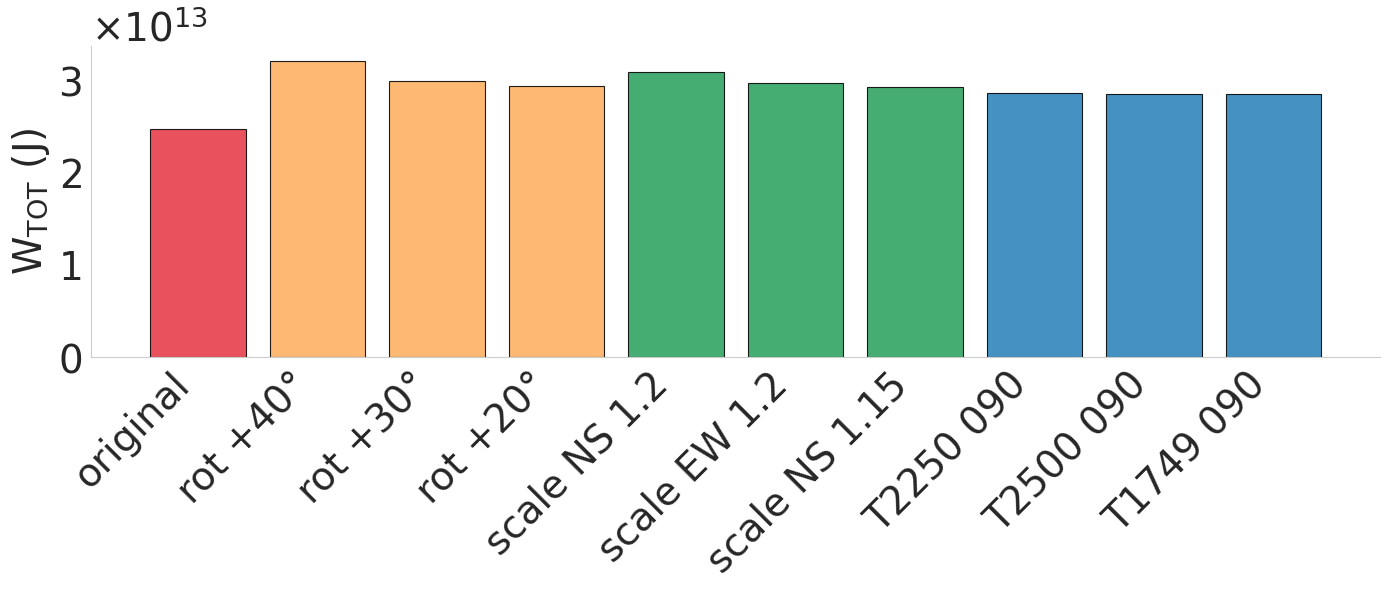

/tmp/ipykernel_1954915/2930136818.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_fine_grid_gravitational_work_three_rows.png
Salvato PDF: /home/fbellisardi/code/topolity/output/wtot/santiago/fine_grid_gravitational_work_restored.pdf


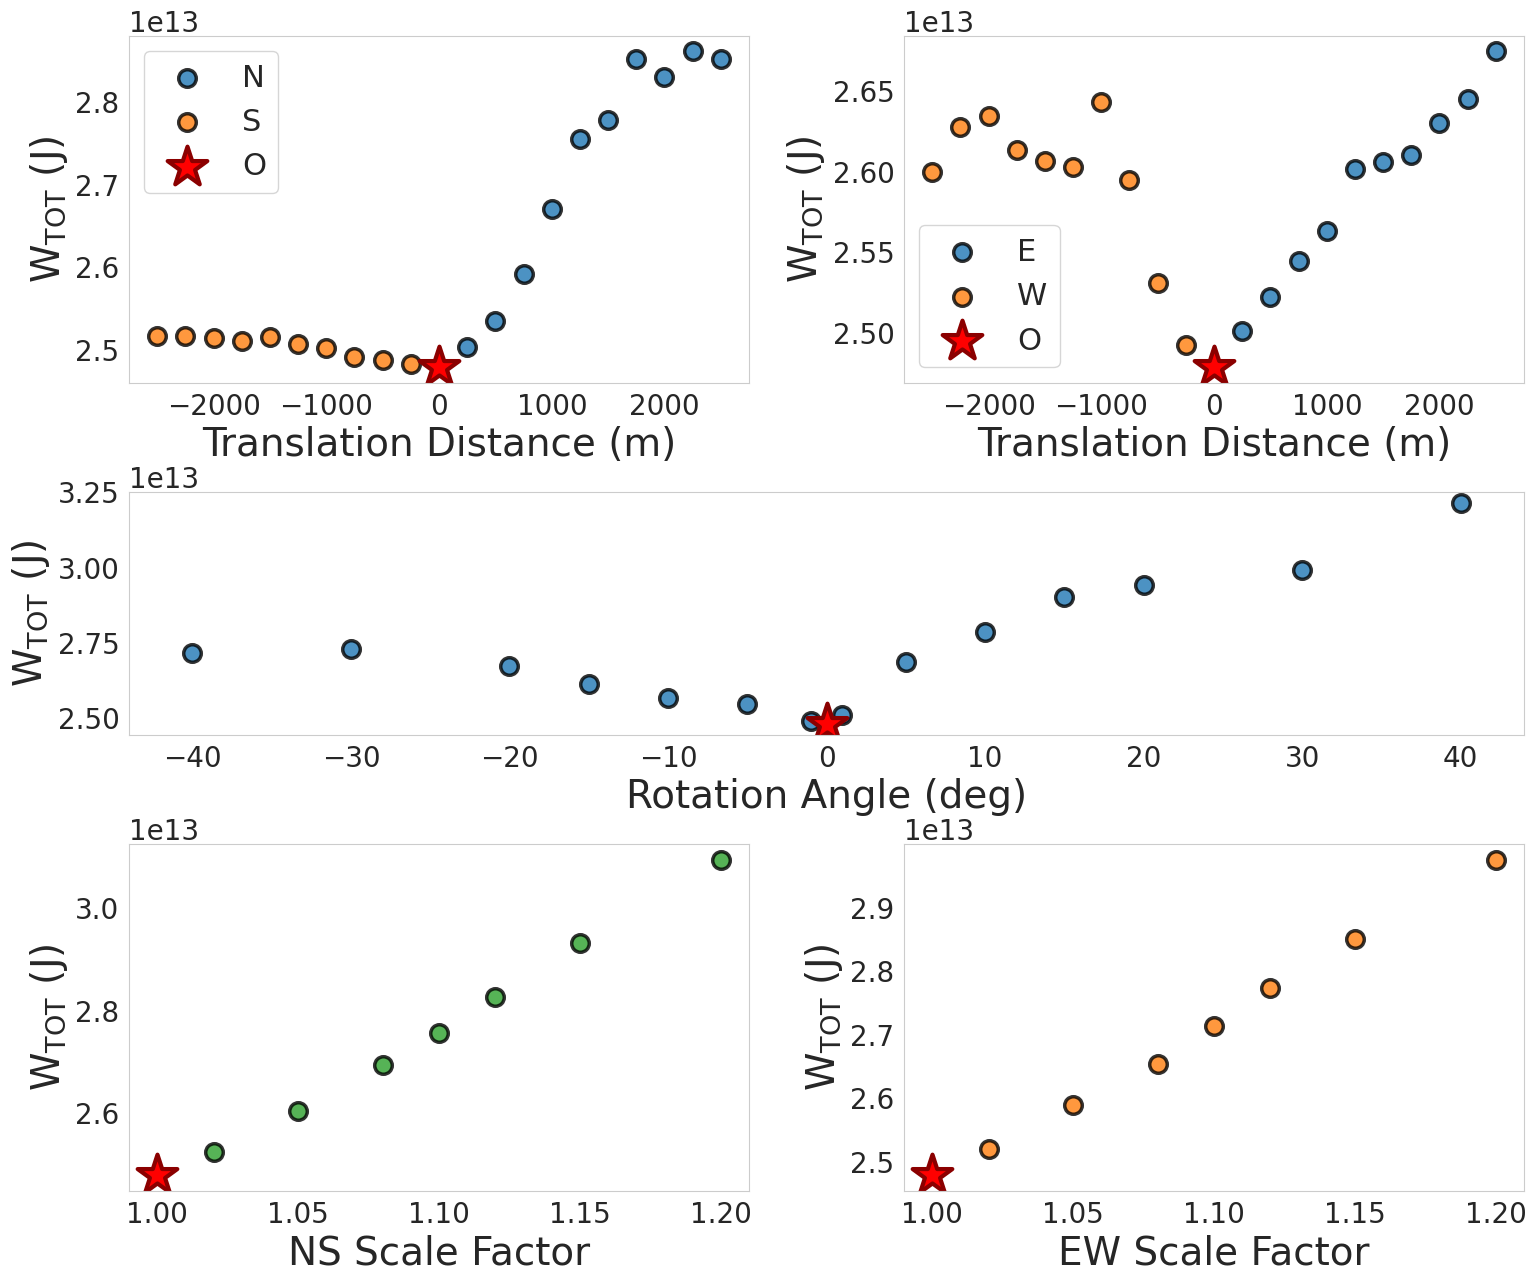

Plots displayed (SAVE=False -> not saved).


In [137]:
# Genera il grafico per la città impostata in `CITY` e visualizza i plot in-notebook (SAVE=False per non salvare file)
try:
    df = load_all_results(CITY, source_filter=SOURCE_FILTER)
    print(f"Caricati {len(df)} record per {CITY}")

    # Imposta energy_plot: priorità a `total_energy_3d_J`, poi fallback a colonne storiche
    if "total_energy_3d_J" in df.columns:
        df["energy_plot"] = df["total_energy_3d_J"]
    elif "total_work_3d" in df.columns:
        df["energy_plot"] = df["total_work_3d"]
    elif "total_work" in df.columns:
        df["energy_plot"] = df["total_work"]
    elif "work_wd" in df.columns and "work_hol" in df.columns:
        df["energy_plot"] = df["work_wd"] + df["work_hol"]
    else:
        raise KeyError("Colonna per energy_plot non trovata (attese: total_energy_3d_J, total_work_3d o total_work)")

except Exception as e:
    print(f"Errore caricamento {CITY}:", e)
    raise

print(CITY, "data loaded successfully. Ready to plot.")

# DIAGNOSTICA: mostro le traduzioni e se vengono considerate cardinali secondo la regola unificata
# Calcolo statistiche rapide per debugging: quante translation totali, quante sopra soglia, quante cardinali
if "transformation_type" not in df.columns:
    type_source = df["variant_type"] if "variant_type" in df.columns else df["variant"]
    df["transformation_type"] = type_source.astype(str).apply(classify_transformation_type)

df["__param_num"] = df.apply(_num_param_from_row, axis=1)

trans_all = df[df["transformation_type"].astype(str).str.lower() == "translation"].copy()
print(f"Totale righe classify 'translation': {len(trans_all)}")

trans_above_thresh = trans_all[trans_all["__param_num"].notna() & (trans_all["__param_num"] >= TRANSLATION_DISTANCE_THRESHOLD)].copy()
print(f"- Traduzioni con distanza numerica >= {TRANSLATION_DISTANCE_THRESHOLD} m: {len(trans_above_thresh)}")

trans_cardinal = trans_above_thresh[trans_above_thresh.apply(is_cardinal_translation_row, axis=1)].copy()
print(f"- Di queste, cardinali secondo la regola (numero in {{0,90,180,270}} o keyword): {len(trans_cardinal)}")

# Mostro sample e nomi per verificare
if not trans_above_thresh.empty:
    print('\nEsempi traduzioni sopra soglia (max 10):')
    display(trans_above_thresh.head(10)[["variant","variant_type","filename","parameter","__param_num"]])

if not trans_cardinal.empty:
    print('\nEsempi traduzioni cardinali selezionate (max 10):')
    display(trans_cardinal.head(10)[["variant","variant_type","filename","parameter","__param_num",]])

# continua con i plot (usando le funzioni aggiornate)
out_png = Path(f"/home/fbellisardi/code/topolity/output/wtot/{CITY}/{CITY}_combined_work_comparison.png")
out_png.parent.mkdir(parents=True, exist_ok=True)

# Display combined bar plot (will not save files when SAVE=False)
plot_combined_work_comparison(df, out_png)

# Display three-row comparison inline (does not force saving)
out_png_three = OUTPUT_DIR / f"{CITY}_fine_grid_gravitational_work_three_rows.png"
plot_restored_work_vs_parameter(df, out_png=out_png_three)

print("Plots displayed (SAVE=False -> not saved).")

Salvato PNG: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_boxplot_by_transformation.png
Salvato PDF: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_boxplot_by_transformation.pdf


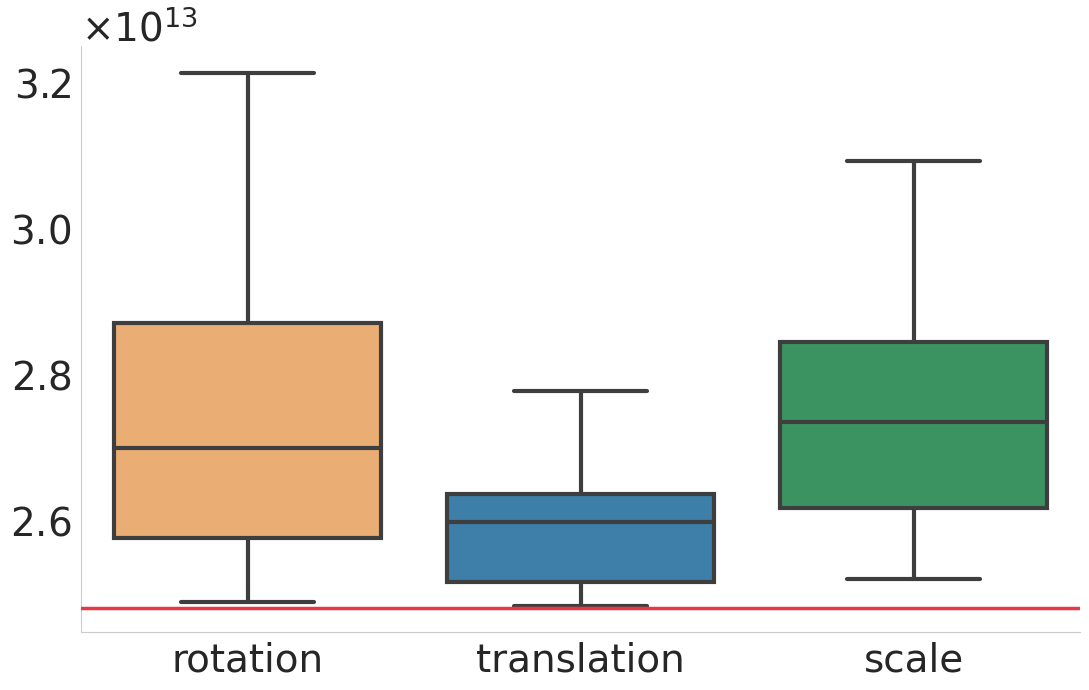

Boxplot generated: /home/fbellisardi/code/topolity/output/wtot/santiago/santiago_boxplot_by_transformation.png


In [138]:
# Cell added: generate and display boxplot by transformation
try:
    out_png = run_boxplot(df, source_filter=SOURCE_FILTER)
    print(f"Boxplot generated: {out_png}")
except Exception as e:
    print("Errore generazione boxplot:", e)
    raise

In [139]:
# ═══════════════════════════════════════════════════════════════════════════════
# MAPPA 1/2 — Configurazione ORIGINALE
# Mostrata solo se esiste una configurazione con energia più bassa.
# ═══════════════════════════════════════════════════════════════════════════════
import pickle, math
import geopandas as gpd
import contextily as ctx
import matplotlib.patheffects as pe
from shapely.geometry import LineString
from matplotlib.lines import Line2D

# ── Individua la migliore configurazione ─────────────────────────────────────
_ecol = "energy_plot"
_df_work = df.copy()
_orig_rows = _df_work[_df_work["transformation_type"] == "original"]
assert not _orig_rows.empty, "Riga 'original' non trovata nel dataframe."

_orig_energy = float(_orig_rows[_ecol].iloc[0])
_best_row    = _df_work.loc[_df_work[_ecol].idxmin()]
_best_energy = float(_best_row[_ecol])
_delta_pct   = 100 * (_best_energy / _orig_energy - 1)

if _best_row["transformation_type"] == "original":
    print(f"✓ {CITY}: l'originale è già il minimo energetico ({_orig_energy:.3e} J). "
          "Nessun controesempio — questa cella non produce mappe.")
else:
    print(f"⚠ {CITY}: controesempio trovato  Δ = {_delta_pct:.3f}%")
    _best_fn = str(_best_row.get("filename", _best_row.get("variant", "")))
    if not _best_fn.endswith(".pkl"):
        _best_fn = f"graph_{_best_fn}.pkl"
    print(f"  Originale : {_orig_energy:.4e} J")
    print(f"  Migliore  : {_best_energy:.4e} J  [{_best_fn}]")

    # ── Carica grafi ─────────────────────────────────────────────────────────
    _fg_dir = BASE_DIR / CITY / "graphs_fine_grid"
    with open(_fg_dir / "graph_original.pkl", "rb") as _f:
        _G_orig = pickle.load(_f)
    with open(_fg_dir / _best_fn, "rb") as _f:
        _G_best = pickle.load(_f)

    # ── Helper ───────────────────────────────────────────────────────────────
    def _to_gdf(G):
        recs = []
        for u, v, data in G.edges(data=True):
            geom = data.get("geometry") or LineString(
                [(G.nodes[u]["x"], G.nodes[u]["y"]),
                 (G.nodes[v]["x"], G.nodes[v]["y"])])
            recs.append({"geometry": geom})
        return gpd.GeoDataFrame(recs, geometry="geometry", crs="EPSG:4326")

    def _centroid(G):
        xs = [d["x"] for _, d in G.nodes(data=True)]
        ys = [d["y"] for _, d in G.nodes(data=True)]
        return float(sum(xs) / len(xs)), float(sum(ys) / len(ys))

    def _haversine_km(lon1, lat1, lon2, lat2):
        R = 6371.0
        p1, p2 = math.radians(lat1), math.radians(lat2)
        a = (math.sin((p2 - p1) / 2) ** 2
             + math.cos(p1) * math.cos(p2) * math.sin(math.radians(lon2 - lon1) / 2) ** 2)
        return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    _gdf_orig = _to_gdf(_G_orig)
    _gdf_best = _to_gdf(_G_best)
    _c_orig   = _centroid(_G_orig)
    _c_best   = _centroid(_G_best)
    _dx = _c_best[0] - _c_orig[0]
    _dy = _c_best[1] - _c_orig[1]

    # Per traslazioni: mostra il grafo originale traslato (stessa topologia)
    _family = str(_best_row.get("transformation_type", "")).lower()
    if "translation" in _family or "trans" in _best_fn:
        _gdf_show_best = _gdf_orig.copy()
        _gdf_show_best["geometry"] = _gdf_show_best.geometry.translate(xoff=_dx, yoff=_dy)
        _shift_km = _haversine_km(_c_orig[0], _c_orig[1], _c_best[0], _c_best[1])
        _dir = ("E" if _dx > 0 else "W") if abs(_dx) > abs(_dy) else ("N" if _dy > 0 else "S")
        _shift_txt = f"Translation {_shift_km:.2f} km, direction {_dir}"
    elif "rotation" in _family or "rot" in _best_fn:
        _gdf_show_best = _gdf_best
        _angle = _best_row.get("parameter", "?")
        _shift_txt = f"rotation {_angle}°"
    else:
        _gdf_show_best = _gdf_best
        _shift_txt = f"best transformation ({_family})"

    # ── Bounds comuni ─────────────────────────────────────────────────────────
    _bnd = (
        min(_gdf_orig.total_bounds[0], _gdf_show_best.total_bounds[0]),
        min(_gdf_orig.total_bounds[1], _gdf_show_best.total_bounds[1]),
        max(_gdf_orig.total_bounds[2], _gdf_show_best.total_bounds[2]),
        max(_gdf_orig.total_bounds[3], _gdf_show_best.total_bounds[3]),
    )
    _px = (_bnd[2] - _bnd[0]) * 0.06
    _py = (_bnd[3] - _bnd[1]) * 0.06
    _xlim = (_bnd[0] - _px, _bnd[2] + _px)
    _ylim = (_bnd[1] - _py, _bnd[3] + _py)

    # ════════════════════════════════════════════════
    # MAPPA 1 — Configurazione ORIGINALE
    # ════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(*_xlim); ax.set_ylim(*_ylim)

    _gdf_orig.plot(ax=ax, color="#f97316", linewidth=1.2, alpha=0.9, zorder=4)
    try:
        ctx.add_basemap(ax, crs="EPSG:4326",
                        source=ctx.providers.CartoDB.Positron,
                        attribution_size=6, zoom="auto")
    except Exception as _e:
        print(f"  (basemap non disponibile: {_e})")
    ax.set_xlim(*_xlim); ax.set_ylim(*_ylim)

    # Centroide
    ax.scatter([_c_orig[0]], [_c_orig[1]], s=70, color="#b45309",
               edgecolor="white", linewidth=1.2, zorder=6)
    ax.text(_c_orig[0] + (_xlim[1] - _xlim[0]) * 0.018,
            _c_orig[1] + (_ylim[1] - _ylim[0]) * 0.01,
            "centroide", color="#b45309", fontsize=22, zorder=7,
            path_effects=[pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

    ax.set_title(
        f"{CITY.title()} — Configurazione originale\n"
        f"$W_{{\\mathrm{{Tot}}}}$ = {_orig_energy:.3e} J   |   "
        f"$\\Delta$ rispetto al minimo = {_delta_pct:+.2f}%",
        fontsize=13, pad=8)
    ax.set_xlabel("Longitudine", fontsize=22)
    ax.set_ylabel("Latitudine", fontsize=22)
    ax.grid(True, color="#94a3b8", alpha=0.3, linewidth=0.5)
    ax.legend(handles=[Line2D([0],[0], color="#f97316", lw=2, label="Original Network")],
              frameon=False, loc="upper right", fontsize=22)

    plt.tight_layout()
    if SAVE:
        _p = OUTPUT_DIR / f"{CITY}_mappa_originale.png"
        _p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(_p, dpi=300, bbox_inches="tight")
        fig.savefig(_p.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Salvato: {_p}")
    plt.show()
    print(f"\nPer la mappa della configurazione migliore, esegui la cella successiva.")

✓ santiago: l'originale è già il minimo energetico (2.479e+13 J). Nessun controesempio — questa cella non produce mappe.


In [140]:
# ════════════════════════════════════════════════
# MAPPA 2 — Configurazione con ENERGIA MINIMA
# Richiede che la cella precedente sia stata eseguita.
# ════════════════════════════════════════════════
try:
    _gdf_show_best   # verifica che la cella precedente abbia trovato un controesempio
except NameError:
    print("Nessun controesempio trovato: l'originale è già il minimo. Cella saltata.")
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(*_xlim); ax.set_ylim(*_ylim)

    _gdf_show_best.plot(ax=ax, color="#1d4ed8", linewidth=1.2, alpha=0.9, zorder=4)
    try:
        ctx.add_basemap(ax, crs="EPSG:4326",
                        source=ctx.providers.CartoDB.Positron,
                        attribution_size=6, zoom="auto")
    except Exception as _e:
        print(f"  (basemap non disponibile: {_e})")
    ax.set_xlim(*_xlim); ax.set_ylim(*_ylim)

    # Centroide della configurazione migliore
    _c_show = (
        _c_orig[0] + _dx if "translation" in _family or "trans" in _best_fn else _c_best[0],
        _c_orig[1] + _dy if "translation" in _family or "trans" in _best_fn else _c_best[1],
    )
    ax.scatter([_c_show[0]], [_c_show[1]], s=70, color="#1d4ed8",
               edgecolor="white", linewidth=1.2, zorder=6)
    ax.text(_c_show[0] + (_xlim[1] - _xlim[0]) * 0.018,
            _c_show[1] + (_ylim[1] - _ylim[0]) * 0.01,
            "centroide", color="#1d4ed8", fontsize=22, zorder=7,
            path_effects=[pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

    # Etichetta con la descrizione della trasformazione
    ax.text(0.02, 0.98, _shift_txt,
            transform=ax.transAxes, ha="left", va="top", fontsize=16,
            bbox={"facecolor": "white", "edgecolor": "#64748b",
                  "alpha": 0.92, "boxstyle": "round,pad=0.3"},
            zorder=7)

    ax.set_title(
        f"{CITY.title()} — Configurazione con energia minima ({_shift_txt})\n"
        f"$W_{{\\mathrm{{Tot}}}}$ = {_best_energy:.3e} J   |   "
        f"$\\Delta$ = {_delta_pct:+.2f}% rispetto all'originale",
        fontsize=13, pad=8)
    ax.set_xlabel("Longitudine", fontsize=22)
    ax.set_ylabel("Latitudine", fontsize=22)
    ax.grid(True, color="#94a3b8", alpha=0.3, linewidth=0.5)
    # ax.legend(handles=[Line2D([0],[0], color="#1d4ed8", lw=2, label="Transformed Network")],
    #           frameon=False, loc="lower right", fontsize=22)

    plt.tight_layout()
    if SAVE:
        _p = OUTPUT_DIR / f"{CITY}_mappa_configurazione_migliore.png"
        _p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(_p, dpi=300, bbox_inches="tight")
        fig.savefig(_p.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Salvato: {_p}")
    plt.show()

Nessun controesempio trovato: l'originale è già il minimo. Cella saltata.
